In [26]:
with open('Leps.txt', 'r', encoding='utf-8') as ftr:
    Leps = ftr.read().replace('\n', ' ')

In [27]:
with open('Magomaev.txt', 'r', encoding='utf-8') as ftr:
    Magomaev = ftr.read().replace('\n', ' ')

In [28]:
with open('Shatunov.txt', 'r', encoding='utf-8') as ftr:
    Shatunov = ftr.read().replace('\n', ' ')

In [29]:
songs = [Leps, Magomaev, Shatunov]

In [30]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


$Выполняем$ $предобработку$ $текста$ $песен$

In [35]:
import re
from steosmorphy import MorphAnalyzer
from mawo_pymorphy3 import create_analyzer

# Создаём анализатор

analyzer = create_analyzer()

cleaned_songs = []

punctuation = "!?.,-—…:;()"
for letters in songs:
    # Приведение к нижнему регистру
    letters = letters.lower()

    # Удаляем пунктуацию
    for char in punctuation:
        letters = letters.replace(char, ' ')

    # Убираем лишние пробелы
    letters = re.sub(r'\s+', ' ', letters).strip()

    # Токенизация по пробелам
    tokens = letters.split()

    # Лемматизация через pymorphy2
    clean_tokens = []
    for word in tokens:
        if len(word) <= 2:  # пропускаем очень короткие слова
            continue
        
        parsed = analyzer.parse(word)
        if parsed:
            lemma = parsed[0].normal_form
        else:
            lemma = word
            
        if lemma not in stop_words and lemma.strip() != '' and len(lemma) > 1:
            clean_tokens.append(lemma)
    
    cleaned_songs.append(' '.join(clean_tokens))


print("Предобработанные тексты песен:\n", cleaned_songs, "\n")

Предобработанные тексты песен:
 ['триста тысяча час спина триста тысяча планет устать создатель небо кружить каждый просыпаться рассвет неспроста вспоминать это очень здорово весь жить самый хороший день заходить вчера ночь ехать лень пробыть утро прийти пора собраться путь ладно самый хороший день заходить вчера ночь ехать лень пробыть утро прийти пора собраться путь ладно главное выйти мода согласно закон природа весь вгрызаться мир рыба пила оставаться лишь тонкий нить русски упомнить английски стать love самый хороший день заходить вчера ночь ехать лень пробыть утро прийти пора собраться путь ладно самый хороший день заходить вчера ночь ехать лень пробыть утро прийти пора собраться путь ладно', 'море вернуться говор чаёк песня прибой рассвет пробудить сердце друг море встречать сердце песня лететь грудь море море преданный скал ненадолго подарить прибой море взять дальний даль парус алым вместе грустный звезда поиск ласка сквозь синий вечность лететь земля море навстречу детская ск

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

import time

$Сравнение$ $разных$ $векторизаторов$

In [70]:
start = time.time()
tfidf_vectorizer = TfidfVectorizer(use_idf=True)

#Создание матрицы

tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_songs)
end = time.time()

print(f"TF-IDF time: {end - start} seconds")  # время работы метода TF-IDF

TF-IDF time: 0.0049974918365478516 seconds


In [72]:
start = time.time()
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(cleaned_songs)
end = time.time()
print(f"CountVectorizer: {end - start} seconds")  # время работы метода CountVectorizer

CountVectorizer: 0.0029954910278320312 seconds


In [53]:
start = time.time()
sentences = [txt.split() for txt in cleaned_songs]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
end = time.time()
print(f"Word2Vec: {end - start} seconds")  # время работы метода Word2Vec

Word2Vec: 0.04999852180480957 seconds


$Быстрее$ $всего$ $работает$ $CountVectorizer,$ $в$ $то$ $время$ $как$ $Word2Vec$ $работает$ $медленнее$ $всего$

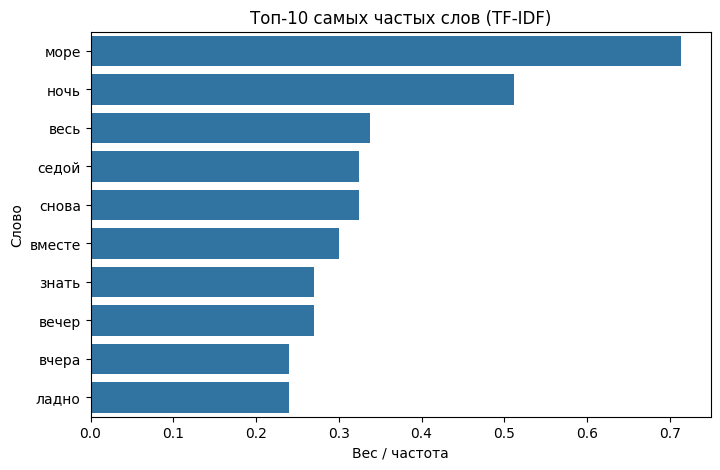

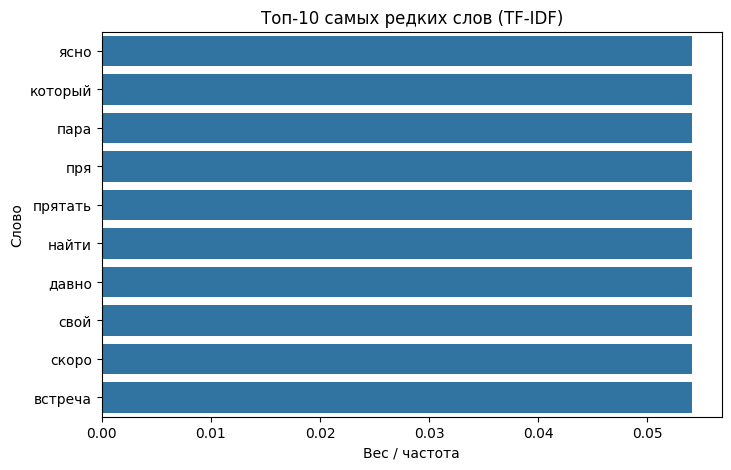

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для TF-IDF
word_counts = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
df = pd.DataFrame({"word": tfidf_vectorizer.get_feature_names_out(), "count": word_counts})

# Топ-10 самых частых слов
df_top = df.sort_values("count", ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_top)
plt.title("Топ-10 самых частых слов (TF-IDF)")
plt.xlabel("Вес / частота")
plt.ylabel("Слово")
plt.show()

# Топ-10 самых редких слов (исключая нулевые)
df_bottom = df[df["count"] > 0].sort_values("count", ascending=True).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_bottom)
plt.title("Топ-10 самых редких слов (TF-IDF)")
plt.xlabel("Вес / частота")
plt.ylabel("Слово")
plt.show()

In [81]:
df_top.head(10)

,word,count
51,море,0.713598
61,ночь,0.511825
6,весь,0.338233
90,седой,0.324724
99,снова,0.324724
12,вместе,0.300318
38,знать,0.270603
7,вечер,0.270603
16,вчера,0.240023
43,ладно,0.240023


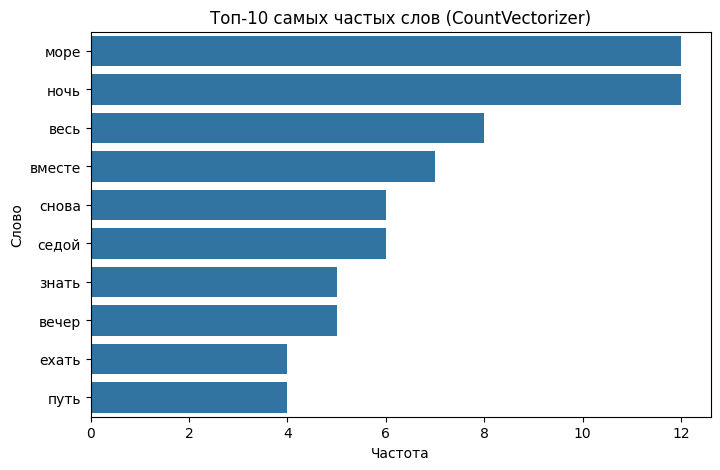

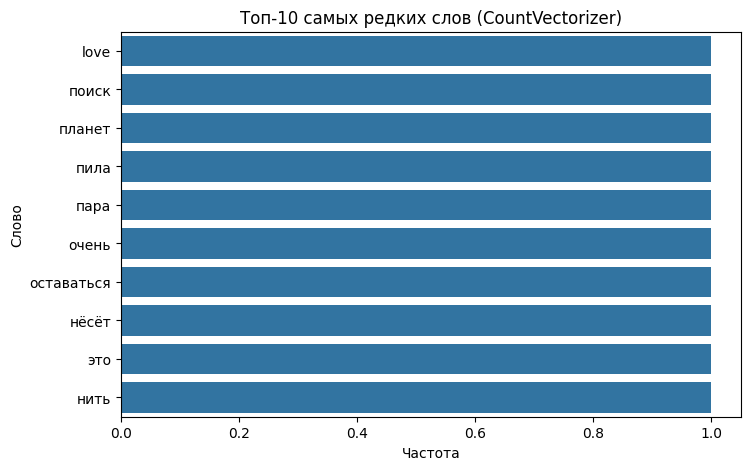

In [74]:
# Для CountVectorizer 
word_counts_cv = np.asarray(count_matrix.sum(axis=0)).flatten()
df_cv = pd.DataFrame({"word": count_vectorizer.get_feature_names_out(), "count": word_counts_cv})

df_top_cv = df_cv.sort_values("count", ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_top_cv)
plt.title("Топ-10 самых частых слов (CountVectorizer)")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()

df_bottom_cv = df_cv[df_cv["count"] > 0].sort_values("count", ascending=True).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_bottom_cv)
plt.title("Топ-10 самых редких слов (CountVectorizer)")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()

In [80]:
df_top_cv.head(10)

,word,count
51,море,12
61,ночь,12
6,весь,8
12,вместе,7
99,снова,6
90,седой,6
38,знать,5
7,вечер,5
30,ехать,4
83,путь,4


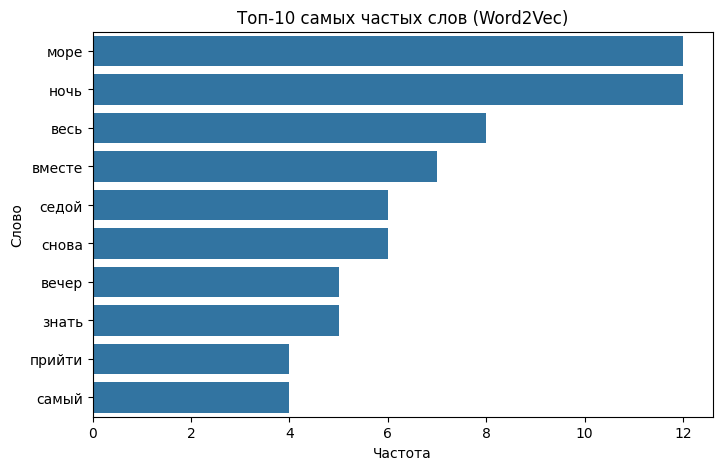

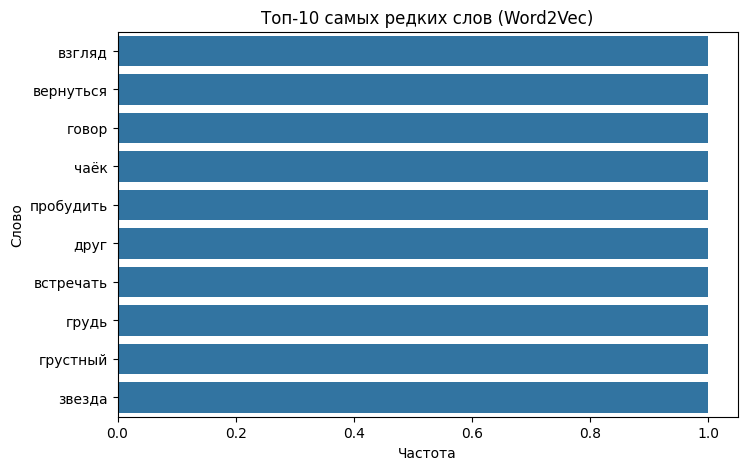

In [77]:
# Получаем слова и их частоты из модели
words = list(w2v_model.wv.key_to_index.keys())
# Word2Vec хранит частоты во внутреннем словаре
word_counts_w2v = [(word, w2v_model.wv.get_vecattr(word, 'count')) for word in words]
df_w2v = pd.DataFrame(word_counts_w2v, columns=["word", "count"])

# Топ-10 самых частых слов
df_top_w2v = df_w2v.sort_values("count", ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_top_w2v)
plt.title("Топ-10 самых частых слов (Word2Vec)")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()

# Топ-10 самых редких слов 
df_bottom_w2v = df_w2v.sort_values("count", ascending=True).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_bottom_w2v)
plt.title("Топ-10 самых редких слов (Word2Vec)")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()


In [ ]:
df_top_w2v.head(10)

,word,count
0,море,12
1,ночь,12
2,весь,8
3,вместе,7
4,седой,6
5,снова,6
6,вечер,5
7,знать,5
17,прийти,4
26,самый,4


# Сравнение частоты слов по методам

## CountVectorizer
**Частые слова:** `море`, `ночь`, `весь`, `вместе`, `снова`  
> Это общеупотребительные слова, которые встречаются часто, обычно в двух песнях или в одной, но особенно часто как слово `море`

**Редкие слова:** `love`, `поиск`, `планет`, `пила`  
> Встречаются только в одной песне и только один раз. `love` например единственное английское слово во всех трех песнях.

---

## TF-IDF
**Частые слова:** `море`, `ночь`, `весь`, `седой`, `снова` 
> Слово море имеет самый большой вес, часто встречается в одной конкретной песне. 
TF-IDF может придавать большой вес слову, которое встречается очень часто, но только в одной песне, из-за его уникальности.

**Редкие слова:** `ясный`, `который`, `пара`, `прятать`  
> Слова, которые встречаются мало или равномерно распределены.

---

## Word2Vec
**Частые слова:** `море`, `ночь`, `весь`, `вместе`, `седой`   
> Слова с высокой встречаемостью в обучении. Результат аналогичен CountVectorizer

**Редкие слова:** `взгляд`, `вернуться`, `говор`, `чаек`  
> Слова, встречающиеся 1 раз.

---

### **Вывод:**
В целом, список часто встречающихся слов не меняется, а вот редко встречающихся отличается для каждого метода.

$Строим$ $визуализации$ $облако$ $слов$ $для$ $TF-IDF$

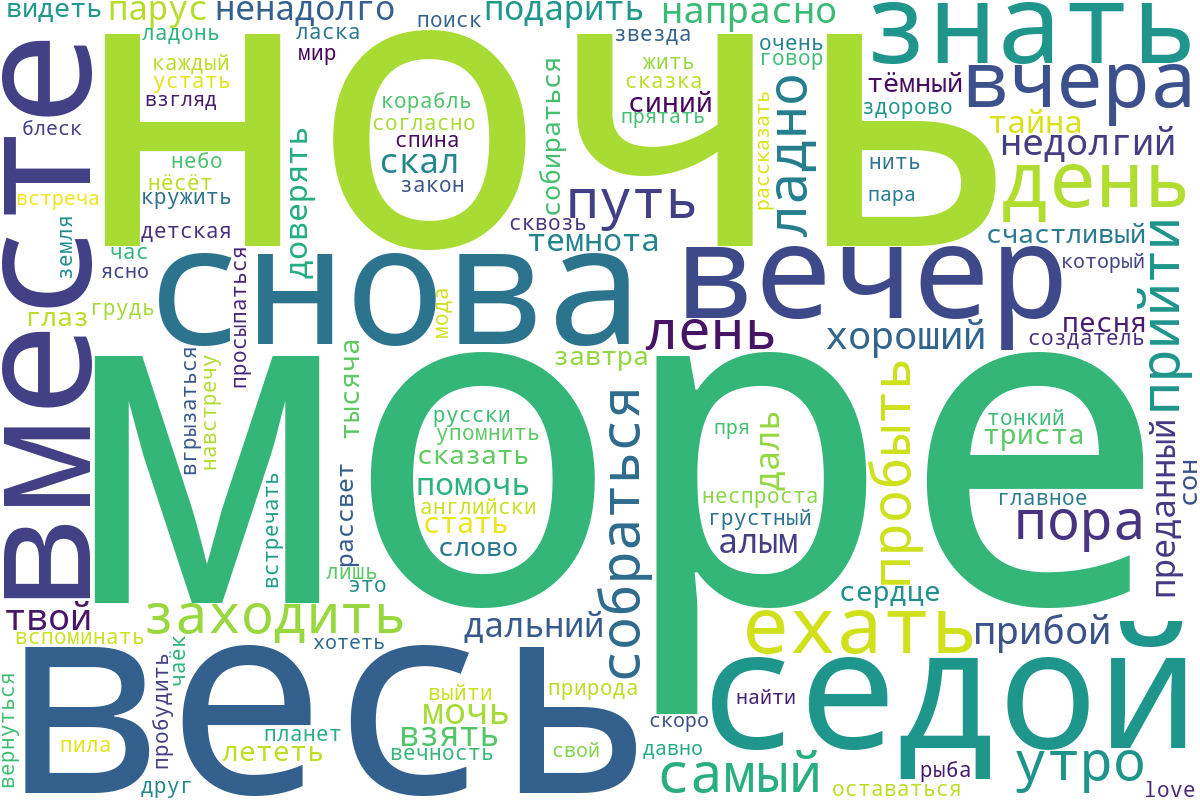

In [103]:
from wordcloud import WordCloud
import numpy as np

# Получаем суммарные TF-IDF веса для всех слов
word_tfidf = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
words = tfidf_vectorizer.get_feature_names_out()

# Создаем словарь {слово: tfidf_вес}
tfidf_dict = dict(zip(words, word_tfidf))

# Создаем облако слов
cloud = WordCloud(width=1200, height=800, background_color='#FFFFFF')
cloud.generate_from_frequencies(tfidf_dict)
cloud.to_image()

$Строим$ $визуализации$ $облако$ $слов$ $для$ $CountVectorizer $

TF-IDF облако слов:


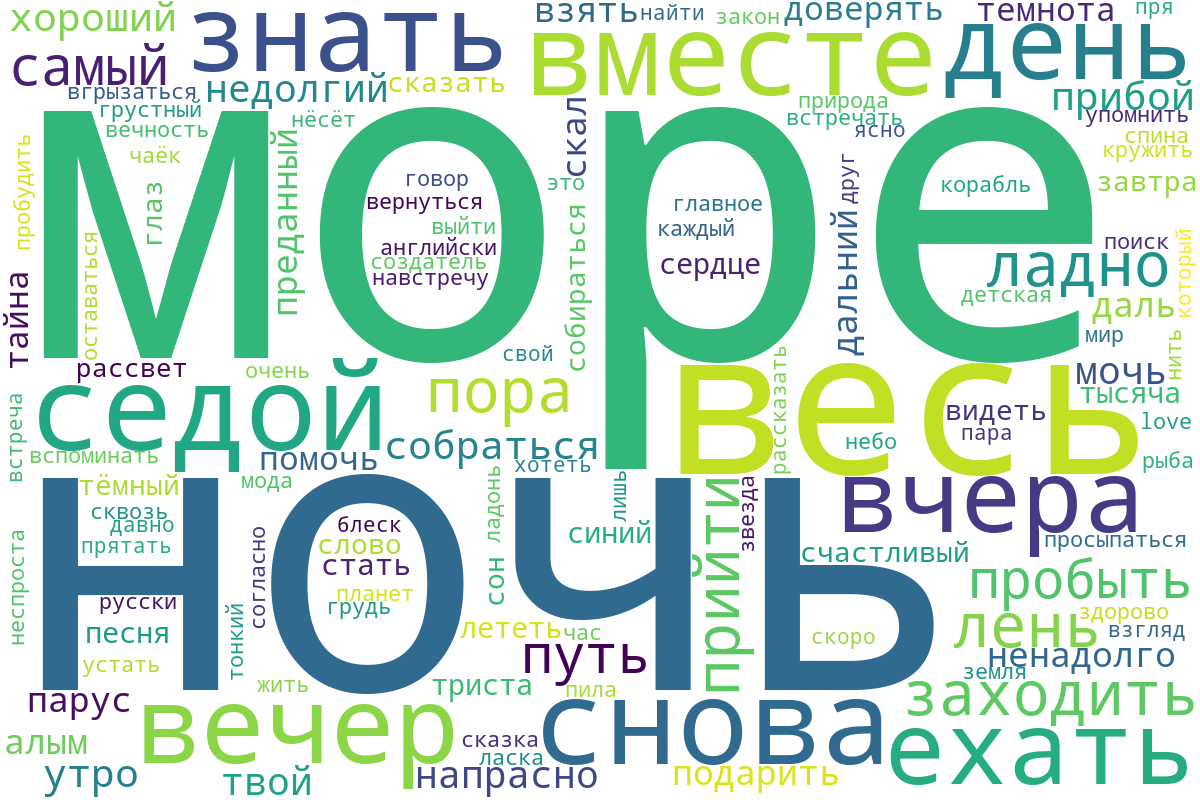


CountVectorizer облако слов (частоты):


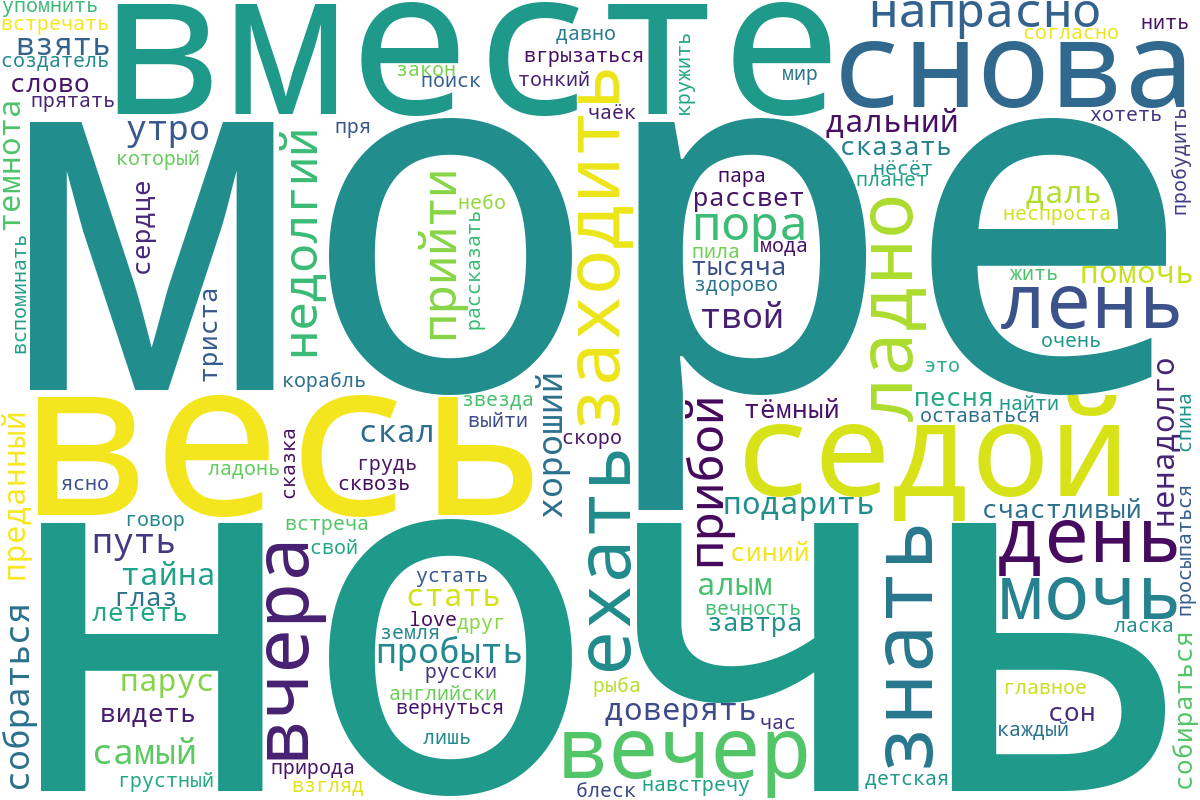

In [111]:
from wordcloud import WordCloud
import numpy as np
from IPython.display import display

# TF-IDF облако
word_tfidf = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
words_tfidf = tfidf_vectorizer.get_feature_names_out()
tfidf_dict = dict(zip(words_tfidf, word_tfidf))

cloud_tfidf = WordCloud(width=1200, height=800, background_color='#FFFFFF')
cloud_tfidf.generate_from_frequencies(tfidf_dict)
print("TF-IDF облако слов:")
display(cloud_tfidf.to_image())

# CountVectorizer облако
word_counts = np.asarray(count_matrix.sum(axis=0)).flatten()
words_count = count_vectorizer.get_feature_names_out()
count_dict = dict(zip(words_count, word_counts))

cloud_count = WordCloud(width=1200, height=800, background_color='#FFFFFF')
cloud_count.generate_from_frequencies(count_dict)
print("\nCountVectorizer облако слов (частоты):")
display(cloud_count.to_image())

In [97]:
# Создаем DataFrame из TF-IDF матрицы
df_tfidf = pd.DataFrame(
    tfidf_matrix.T.todense(),
    index=tfidf_vectorizer.get_feature_names_out(),
    columns=[f"Песня {i+1}" for i in range(len(cleaned_songs))]
)

# Находим топ-10 слов по суммарному TF-IDF весу
top_words_total = df_tfidf.sum(axis=1).sort_values(ascending=False).head(10).index

# Создаем DataFrame с топ-10 словами и их весами для каждой песни
top_words_df = df_tfidf.loc[top_words_total].round(4)

# Добавляем колонку с суммарным весом для наглядности
print("\nС Вес топ-10 слов в каждой песне:")
top_words_df_with_sum = top_words_df.copy()
top_words_df_with_sum['Суммарный вес'] = top_words_df.sum(axis=1).round(4)
print(top_words_df_with_sum)


С Вес топ-10 слов в каждой песне:
        Песня 1  Песня 2  Песня 3  Суммарный вес
море     0.0000   0.7136   0.0000         0.7136
ночь     0.1825   0.0000   0.3293         0.5118
весь     0.0913   0.0000   0.2470         0.3383
седой    0.0000   0.0000   0.3247         0.3247
снова    0.0000   0.0000   0.3247         0.3247
вместе   0.0000   0.1357   0.1646         0.3003
знать    0.0000   0.0000   0.2706         0.2706
вечер    0.0000   0.0000   0.2706         0.2706
вчера    0.2400   0.0000   0.0000         0.2400
ладно    0.2400   0.0000   0.0000         0.2400


$t-SNE$ $визуализация$

c:\Python311\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


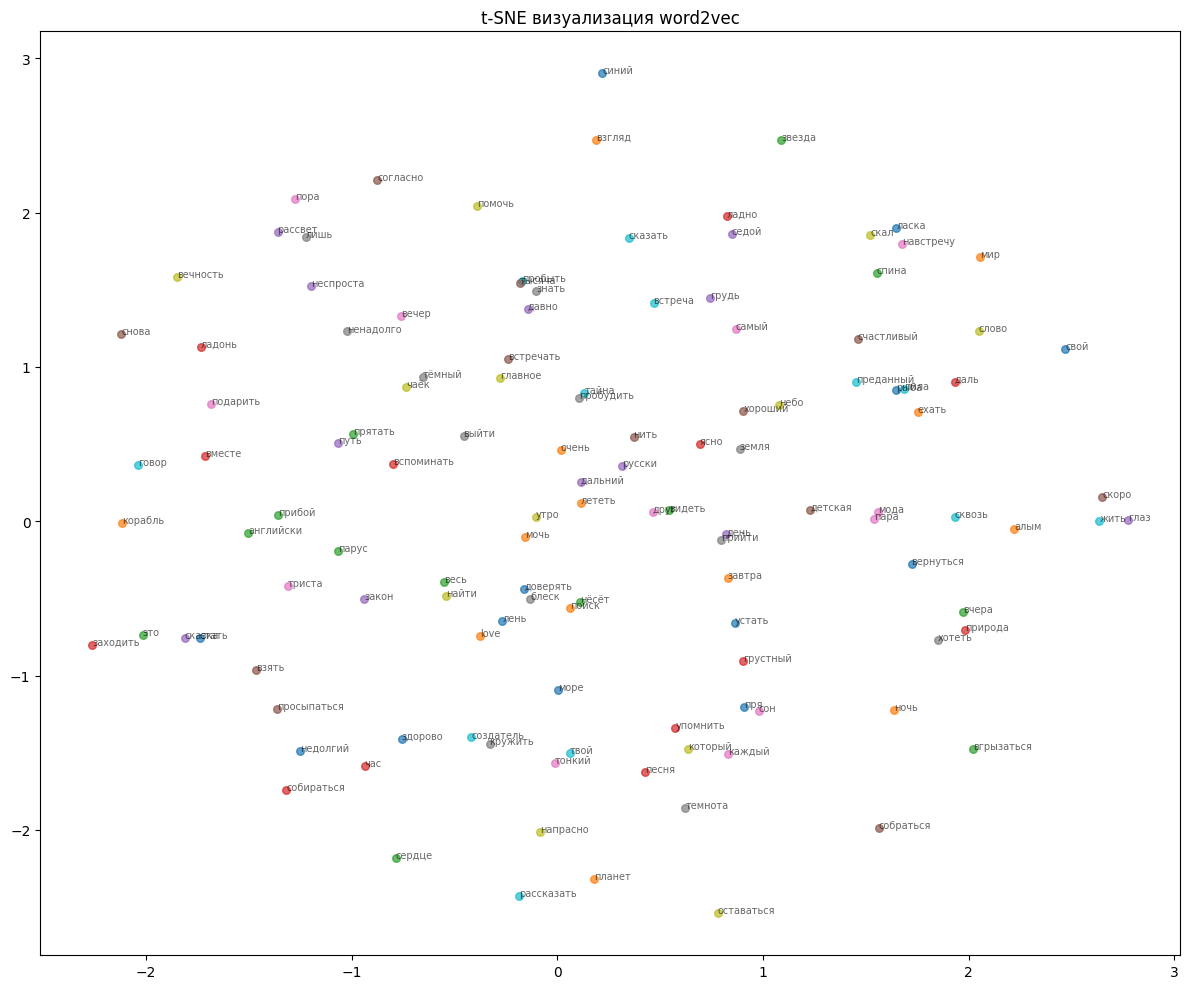

Всего слов на графике: 124


In [112]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Берем первые 500 слов из модели
words = list(w2v_model.wv.key_to_index.keys())
vectors = np.array([w2v_model.wv[word] for word in words])

# t-SNE
tsne = TSNE(perplexity=40, n_components=2, init='pca', n_iter=2500, random_state=23)
result = tsne.fit_transform(vectors)

# График
plt.figure(figsize=(12, 10))
for i in range(len(words)):
    plt.scatter(result[i, 0], result[i, 1], s=30, alpha=0.7)  
    plt.annotate(words[i], (result[i, 0], result[i, 1]), 
                 fontsize=7, alpha=0.6)

plt.title("t-SNE визуализация word2vec")
plt.tight_layout()
plt.show()

print(f"Всего слов на графике: {len(words)}")